In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
from notebooks.circle_plot_utils import (
    get_vectors_by_angle,
    draw_circle,
    draw_dencity,
    z_power_dencity,
)

%load_ext autoreload
%autoreload 2

$$
p(\mathbf{z}|c) = p_{\text{power}}(\mathbf{z}|\boldsymbol{\mu}_c,\kappa) = \frac{\Gamma(\alpha + \beta)}{2^{\alpha + \beta}\pi^{\beta}\Gamma(\alpha)}\left(1 +\boldsymbol{\mu}^T_{c}\mathbf{z}\right)^{\kappa}
$$
$$
\alpha = \frac{d-1}{2} + \kappa,\quad \beta = \frac{d - 1}{2}
$$
$$
p(\mathbf{z}|\mathbf{x}) = p_{\text{power}}(\mathbf{z}|\boldsymbol{\mu}_{\mathbf{x}},\kappa_{\mathbf{x}})
$$
With d=2:

### Create toy data

In [5]:
d = 2  # sphere dimention
K = 3  # num_gallery_classes
M = 20  # support of oog classes
beta = 0.5  # oog class probability
kappa_gallery = 40  # concetration of gallery classes
num_samples = 1000  # number of MC samples
R = 1  # radius of the circle

In [ ]:
class_center_angles = np.array([0, np.pi / 6, np.pi / 4])
class_z_kappa = np.array([kappa_gallery] * K)

probe_center_angles = np.array([np.pi / 2])
probe_z_kappa = np.array([20])
colors = ["tab:green"] * K + ["tab:blue"] * len(probe_z_kappa)

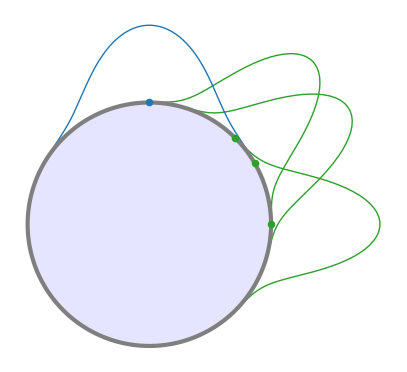

In [ ]:
fontsize = 20
linewidth = 3
dot_size = 80
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax, linewidth)

for color, angle, kappa in zip(
    colors,
    np.concatenate([class_center_angles, probe_center_angles]),
    np.concatenate([class_z_kappa, probe_z_kappa]),
):
    draw_dencity(
        angle,
        kappa,
        ax,
        linewidth=1,
        color=color,
        range=np.pi / 2,
        scale=0.5,
        draw_center=True,
        dot_size=20,
        type="power",
    )

fig.gca().set_aspect("equal")
fig.show()

### Compute posterior $p(c|\textbf{x})$

1. $p(c|\textbf{x}),\, c\in (3,4]$

In [6]:
def compute_p_z(zs, class_center_angles, class_z_kappa):
    """
    compute probability p(z)

    z: set of N z vectors Nx2
    """
    mu_c = get_vectors_by_angle(class_center_angles)
    p_zs = []
    for z in zs:
        p_z = beta / (2 * np.pi * R) + ((1 - beta) / 3) * np.sum(
            [z_power_dencity(z, mu, kappa) for mu, kappa in zip(mu_c, class_z_kappa)]
        )
        p_zs.append(p_z)
    return np.array(p_zs)